#week06 / abalone

컴퓨터공학과 / 202433638 / 장영환

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

path = "/content/drive/MyDrive/Colab Notebooks/인공지능개론/week06/abalone.csv"
df = pd.read_csv(path)

In [ ]:
print("데이터 shape:", df.shape)
print(df.head())
print("\n컬럼별 데이터 타입:")
print(df.dtypes)
print("\n기본 통계:")
print(df.describe())
print("\n결측치 확인:")
print(df.isnull().sum())

데이터 shape: (4177, 10)
   id Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  \
0   0   M   0.455     0.365   0.095        0.5140          0.2245   
1   1   M   0.350     0.265   0.090        0.2255          0.0995   
2   2   F   0.530     0.420   0.135        0.6770          0.2565   
3   3   M   0.440     0.365   0.125        0.5160          0.2155   
4   4   I   0.330     0.255   0.080        0.2050          0.0895   

   Viscera_weight  Shell_weight  Rings  
0          0.1010         0.150     15  
1          0.0485         0.070      7  
2          0.1415         0.210      9  
3          0.1140         0.155     10  
4          0.0395         0.055      7  

컬럼별 데이터 타입:
id                  int64
Sex                object
Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
dtype: object

기본 통계:
                id    

#classification

In [ ]:
df = df.drop('id', axis=1)

sex feature one - hot encoding 진행

In [ ]:
df = pd.get_dummies(df, columns=['Sex'], dtype=int)

Rings를 타깃 데이터로 분류하기에는 너무 연속적인 값으로 분포함으로 3단계로 구간화를 진행한다.

* <=8, 9~10, >=11

* 위에서 분포를 확인해보면 Rings는 8~11 근처에 많이 몰려 있고, 큰 값/작은 값은 적다.
그래서 클래스를 너무 많이 만들면 정확도가 떨어진다

주의할 점 sex는 명목형 범주형 변수임으로 해당 케이스와는 다르다 Rings class는 타깃이므로 정수 라벨 0,1,2로 세팅해도 무방하다(one-hot 필요x)

In [ ]:
df['Rings_class'] = pd.cut(
    df['Rings'],
    bins=[-np.inf, 8, 10, np.inf],
    labels=[0, 1, 2]
).astype(int)

In [ ]:
y = df['Rings_class']
x = df.drop(columns=['Rings', 'Rings_class'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5311 - loss: 0.9460 - val_accuracy: 0.5561 - val_loss: 0.8635
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5576 - loss: 0.8605 - val_accuracy: 0.5830 - val_loss: 0.8437
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5801 - loss: 0.8400 - val_accuracy: 0.5755 - val_loss: 0.8301
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5786 - loss: 0.8360 - val_accuracy: 0.5904 - val_loss: 0.8297
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5846 - loss: 0.8353 - val_accuracy: 0.5904 - val_loss: 0.8210
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5954 - loss: 0.8186 - val_accuracy: 0.5904 - val_loss: 0.8139
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5973 - loss: 0.8168 - val_accuracy: 0.6069 - val_loss: 0.8054
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6171 - loss: 0.8035 - val_accuracy: 0

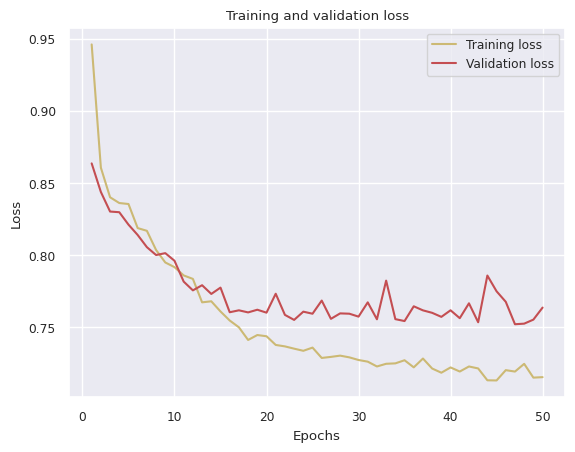

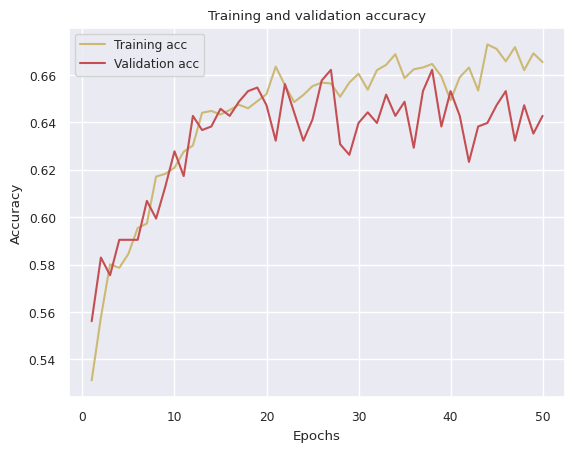

              precision    recall  f1-score   support

           0       0.80      0.73      0.77       281
           1       0.52      0.44      0.47       265
           2       0.62      0.76      0.68       290

    accuracy                           0.65       836
   macro avg       0.65      0.64      0.64       836
weighted avg       0.65      0.65      0.64       836

[[206  49  26]
 [ 40 116 109]
 [ 11  59 220]]


In [ ]:
X_train,X_test, y_train,y_test = train_test_split(x, y,test_size=0.2,random_state=0, stratify=y)


model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(x.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax") #(4177,) 같은 형태라서 현재 클래스가 3개이므로 그냥 명시적으로
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", #타깃 정수 라벨 0, 1, 2
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test)

y_test_class = y_test
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Accuracy of the predicted values
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

#regression

In [ ]:
df2 = pd.read_csv(path)
df2 = df2.drop(['Rings', 'id'], axis=1)

sex feature one - hot encoding 진행

In [ ]:
df2 = pd.get_dummies(df2, columns=['Sex'], dtype=int)

feature 타깃 후보 고르기

In [ ]:
continuous_cols = [
    'Length', 'Diameter', 'Height',
    'Whole_weight', 'Shucked_weight',
    'Viscera_weight', 'Shell_weight'
]

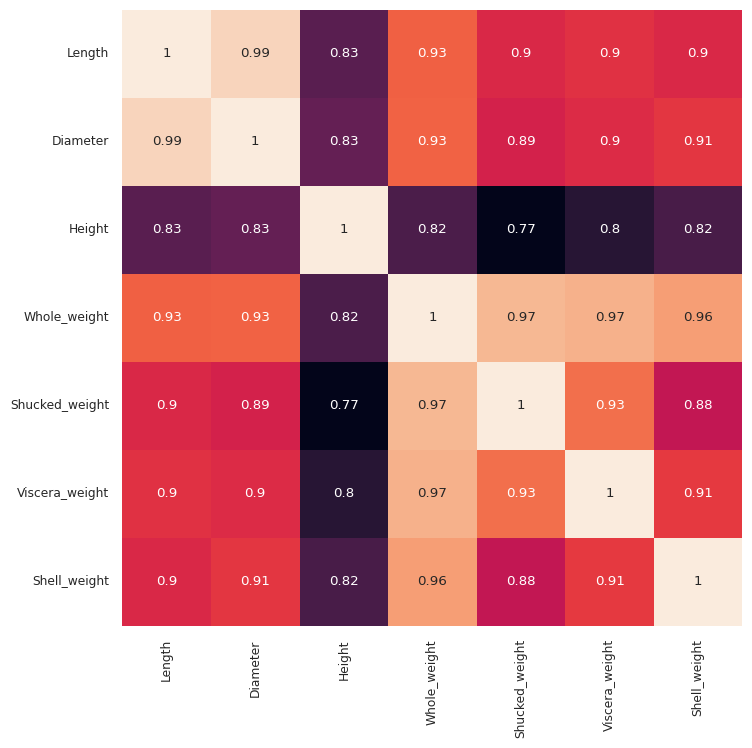

In [ ]:
df_corr = df2[continuous_cols].corr()

plt.figure(figsize=(8, 8))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

whole_weight로 우선 선택

In [ ]:
y=df2['Whole_weight']
X=df2.drop('Whole_weight',axis=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1523 - mae: 0.2542 - val_loss: 0.0096 - val_mae: 0.0713
Epoch 2/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0473 - mae: 0.1328 - val_loss: 0.0070 - val_mae: 0.0621
Epoch 3/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0219 - mae: 0.1072 - val_loss: 0.0107 - val_mae: 0.0761
Epoch 4/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0165 - mae: 0.0931 - val_loss: 0.0067 - val_mae: 0.0580
Epoch 5/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0157 - mae: 0.0857 - val_loss: 0.0054 - val_mae: 0.0518
Epoch 6/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0113 - mae: 0.0753 - val_loss: 0.0069 - val_mae: 0.0593
Epoch 7/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - mae: 0.0720 - val_loss: 0.0045 - val_mae: 0.0477
Epoch 8/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0092 - mae: 0.0677 - val_loss: 0.0085 - val_mae: 0.0673
Epoch 9/50
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0086 

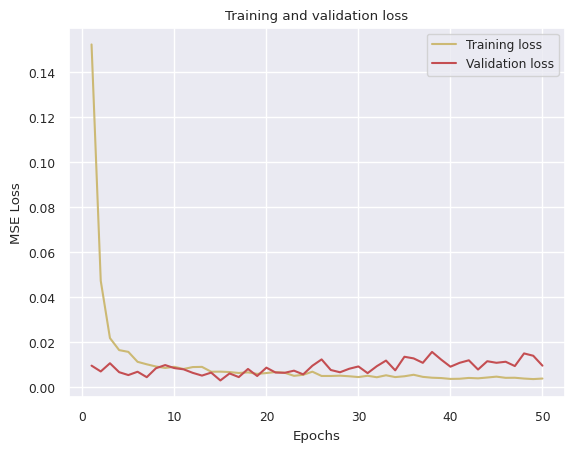

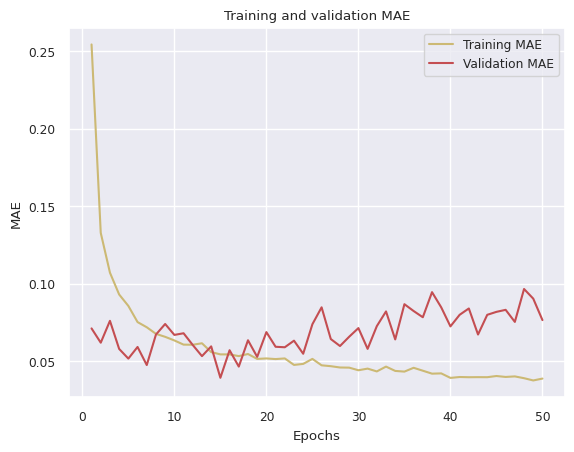

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)

loss = history.history['loss']
val_loss = history.history['val_loss']
mae_hist = history.history['mae']
val_mae_hist = history.history['val_mae']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

plt.plot(epochs, mae_hist, 'y', label='Training MAE')
plt.plot(epochs, val_mae_hist, 'r', label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()